# 05 Evaluate AE Scores and Thresholds

Compute reconstruction scores for the trained convolutional autoencoder, select thresholds only on validation data, and evaluate the held-out test split with frozen thresholds.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    precision_recall_curve
)

In [2]:
# -----------------------------
# paths
# -----------------------------
REPO_ROOT = Path("../..").resolve()

MODEL_PATH = REPO_ROOT / "models/ae_bn16_ma_dataset_20260618.keras"

DATA_ROOT = REPO_ROOT / "data/03_ma_dataset"
TEST_DIR = DATA_ROOT / "test"

IMAGE_SIZE = (150, 100)

# outputs
OUTPUT_DIR = REPO_ROOT / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)

SCORES_PATH = OUTPUT_DIR / "ae_scores.csv"
THRESHOLD_PATH = OUTPUT_DIR / "ae_threshold.json"
METRICS_PATH = OUTPUT_DIR / "ae_metrics.csv"

model = tf.keras.models.load_model(MODEL_PATH)

In [3]:
def load_data(folder, csv_path, target_size=(150, 100)):
    df = pd.read_csv(csv_path)

    images, labels, filenames = [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        file_path = folder / row["filename"]

        
        if not file_path.exists():
            print(f"Missing: {file_path}")
            continue


        img = Image.open(file_path).convert("RGB").resize(target_size)
        img = np.array(img).astype("float32") / 255.0

        images.append(img)
        labels.append(row["label"])   # 0/1 bleibt
        filenames.append(row["filename"])

    return np.array(images), np.array(labels), np.array(filenames)

In [4]:
X_all, y_all, files_all = load_data(
    TEST_DIR,
    TEST_DIR / "labels.csv"
)

# Split: 50% val / 50% test
X_val, X_test, y_val, y_test, f_val, f_test = train_test_split(
    X_all, y_all, files_all,
    test_size=0.5,
    stratify=y_all,
    random_state=42
)

100%|██████████| 5000/5000 [05:07<00:00, 16.24it/s] 


In [5]:
def select_best_f1_threshold(y_true, scores):
    from sklearn.metrics import precision_recall_curve
    import numpy as np

    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    # Edge case
    if len(thresholds) == 0:
        t = float(np.max(scores))
        return {
            "threshold": t,
            "validation_f1": 0.0,
            "validation_precision": 0.0,
            "validation_recall": 0.0
        }

    # F1 berechnen
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)

    best_idx = int(np.nanargmax(f1))

    return {
        "threshold": float(thresholds[best_idx]),
        "validation_f1": float(f1[best_idx]),
        "validation_precision": float(precision[best_idx]),
        "validation_recall": float(recall[best_idx]),
    }

In [6]:
def evaluate_at_threshold(y_true, scores, threshold):
    from sklearn.metrics import (
        average_precision_score,
        f1_score,
        precision_score,
        recall_score,
        confusion_matrix
    )

    y_pred = (scores >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "pr_auc": float(average_precision_score(y_true, scores)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

# VER

In [7]:
def vertical_segment_scores(error_map: np.ndarray, n_segments: int, top_k: int):
    width = error_map.shape[2]

    boundaries = np.linspace(0, width, n_segments + 1, dtype=int)

    segment_scores = []
    for left, right in zip(boundaries[:-1], boundaries[1:]):
        if right <= left:
            continue

        segment_scores.append(
            error_map[:, :, left:right, :].mean(axis=(1, 2, 3))
        )

    segment_scores = np.stack(segment_scores, axis=1)

    ver_max = segment_scores.max(axis=1)

    top_k = min(top_k, segment_scores.shape[1])
    ver_topk = np.sort(segment_scores, axis=1)[:, -top_k:].mean(axis=1)

    return ver_max, ver_topk


def score_reconstructions(model, images):

    recon = model.predict(images, batch_size=32, verbose=0)

    squared_error = (images - recon) ** 2
    absolute_error = np.abs(images - recon)

    ver_max, ver_topk = vertical_segment_scores(
        squared_error,
        n_segments=15,
        top_k=3
    )

    return pd.DataFrame({
        "global_mse": squared_error.mean(axis=(1, 2, 3)),
        "global_mae": absolute_error.mean(axis=(1, 2, 3)),
        "ver_max": ver_max,
        "ver_topk": ver_topk,
    })


In [8]:
val_scores = score_reconstructions(model, X_val)
test_scores = score_reconstructions(model, X_test)

# Evaluate Metrics

In [9]:
score_columns = ["global_mse", "global_mae", "ver_max", "ver_topk"]

results = []
thresholds = {}

for score_name in score_columns:

    # --- Threshold (Validation!)
    selected = select_best_f1_threshold(
        y_val,
        val_scores[score_name].values
    )

    threshold = selected["threshold"]

    thresholds[score_name] = selected

    # --- Test Evaluation
    test_metrics = evaluate_at_threshold(
        y_test,
        test_scores[score_name].values,
        threshold
    )

    results.append({
        "score": score_name,
        "threshold": threshold,
        **test_metrics
    })

results_df = pd.DataFrame(results)
results_df

,score,threshold,pr_auc,f1,precision,recall,tn,fp,fn,tp
0,global_mse,0.001102,0.592720,0.625000,1.0,0.454545,2478,0,12,10
1,global_mae,0.013986,0.324171,0.428571,1.0,0.272727,2478,0,16,6
2,ver_max,0.004584,0.966191,0.926829,1.0,0.863636,2478,0,3,19
3,ver_topk,0.003590,0.923700,0.705882,1.0,0.545455,2478,0,10,12


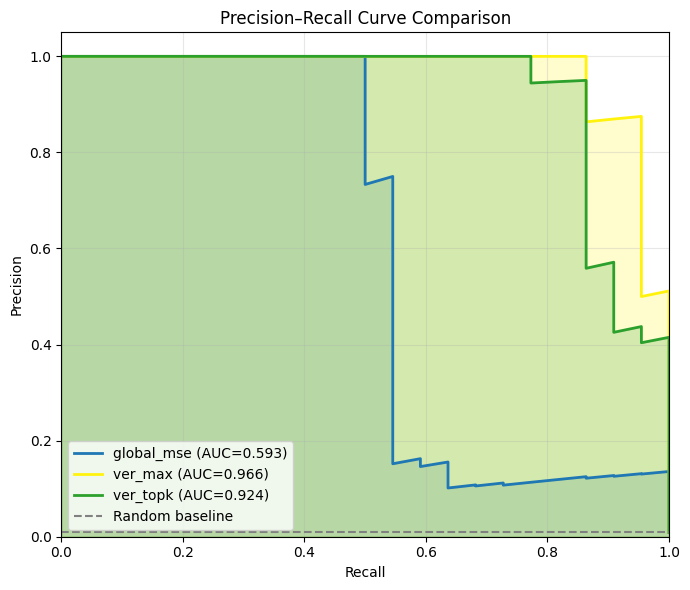

In [10]:
score_columns = ["global_mse", "ver_max", "ver_topk"]

colors = {
    "global_mse": "#1f77b4",  # blau
    "ver_max": "#fff30e",     # orange
    "ver_topk": "#2ca02c"     # grün
}

plt.figure(figsize=(7, 6))

for score in score_columns:
    precision, recall, _ = precision_recall_curve(
        y_test,
        test_scores[score].values
    )

    pr_auc = average_precision_score(
        y_test,
        test_scores[score].values
    )

    color = colors[score]

    # Linie
    plt.plot(
        recall,
        precision,
        label=f"{score} (AUC={pr_auc:.3f})",
        color=color,
        linewidth=2
    )

    # ✅ Transparente Fläche darunter
    plt.fill_between(
        recall,
        precision,
        alpha=0.2,
        color=color
    )

# ✅ Random baseline
baseline = sum(y_test) / len(y_test)
plt.axhline(
    y=baseline,
    linestyle="--",
    color="gray",
    label="Random baseline"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
